# **Projeto:** Classificação de Imagens de Cenários pelo Mundo

**Etapas**


Entendimento e Modelagem do Problema
Problema: Classificar automaticamente imagens de cenários ao redor do mundo em 6 categorias.


**Categorias:** buildings, forest, glacier, mountain, sea, street

**Histórico:** Uma empresa de turismo que colabora com revistas de turismo e sites de viagens tem milhares de imagens arquivadas de suas expedições pelo mundo, mas o seu time sempre enfrenta dificuldades para organizar essas fotos de forma eficiente. Classificar manualmente cada imagem seria uma tarefa demorada e propensa a erros. Para melhorar seu fluxo de trabalho, Clara decidiu buscar uma solução automatizada que conseguisse classificar cada imagem corretamente de acordo com seu cenário.

A empresa de turismo deseja implementar uma solução de Deep Learning que consiga classificar automaticamente cada uma das imagens. A solução permitirá que a empresa organize seu acervo com rapidez e precisão, possibilitando criar catálogos de forma mais eficiente.

### **1. INSTALANDO BIBLIOTECAS E CARREGANDO A BASE DE DADOS**

In [ ]:
# Conectar ao Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install pillow numpy matplotlib tensorflow pydot graphviz keras-visualizer

In [ ]:
# Importação das bibliotecas necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix
import os

In [ ]:
# Caminho do Dataset
dataset_path = (r'/content/drive/MyDrive/02 - Colab Notebooks - Data Science/Python/MBA Fia Labdata - Data Science e Inteligência Artificial/02. Inteligência Artificial II - Prof Carlos Beluzo/6 - Projeto Deep Learning/4 - Projeto_06/Base_de_dados_Projeto06/base_classificacao-imagem-tipos-cenarios-pelo-mundo')

In [ ]:
# Verificação do caminho do dataset
if not os.path.exists(dataset_path):
    print('O caminho especificado não foi encontrado. Verifique o caminho no Google Drive.')
else:
    print('Caminho encontrado!')

Caminho encontrado!


### **2. TRATANDO AS IMAGENS DA BASE DE DADOS**

In [ ]:
# Função para verificar se a imagem está corrompida
def is_valid_image(file_path):
    try:
        img = Image.open(file_path)
        img.verify()
        img = Image.open(file_path)
        img = img.convert('RGB')  # Garantir formato
        img_array = np.array(img)

        # Verificar se a imagem tem dimensões esperadas (3 canais)
        if len(img_array.shape) == 3 and img_array.shape[2] == 3:
            return True
        else:
            print(f'Imagem com formato inválido: {file_path}')
            return False
    except Exception as e:
        print(f'Erro na imagem {file_path}: {e}')
        return False

In [ ]:
# Verificação de categorias
print('Categorias disponíveis:')
category_paths = [os.path.join(dataset_path, d) for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
num_classes = len(category_paths)
for category in category_paths:
    print(f'- {os.path.basename(category)}')

Categorias disponíveis:
- test
- train


In [ ]:
# Montagem do DataFrame com os caminhos completos
file_paths = []
labels = []
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(('jpg', 'jpeg', 'png')):
            full_path = os.path.join(root, file)
            label = full_path.split('/')[-2]  # Pegando o nome da pasta como rótulo
            file_paths.append(full_path)
            labels.append(label)

df = pd.DataFrame({'full_path': file_paths, 'label': labels})

In [ ]:
from PIL import Image

### **3. ANÁLISE EXPLORATÓRA**

In [ ]:
### Análise exploratória, tamanho e visualização das imagens

def show_images_per_class(df, class_column='label', path_column='full_path', img_size=(64, 64), samples_per_class=5):
    unique_labels = df[class_column].unique()
    plt.figure(figsize=(samples_per_class * 2, len(unique_labels) * 2))

    for i, label in enumerate(unique_labels):
        sample_paths = df[df[class_column] == label][path_column].sample(n=samples_per_class, random_state=42)
        for j, img_path in enumerate(sample_paths):
            img = Image.open(img_path).resize(img_size)
            plt.subplot(len(unique_labels), samples_per_class, i * samples_per_class + j + 1)
            plt.imshow(img)
            plt.axis('off')
            if j == 0:
                plt.ylabel(label, fontsize=12)

plt.suptitle("Exemplos de imagens por categoria", fontsize=16)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

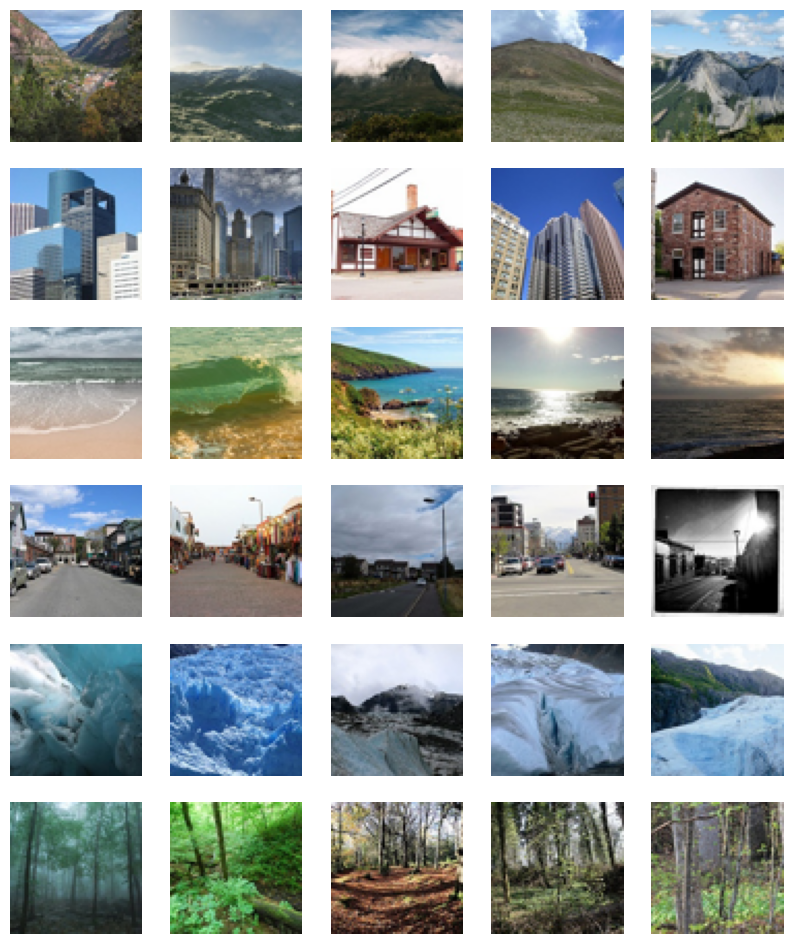

In [ ]:
show_images_per_class(df, samples_per_class=5)

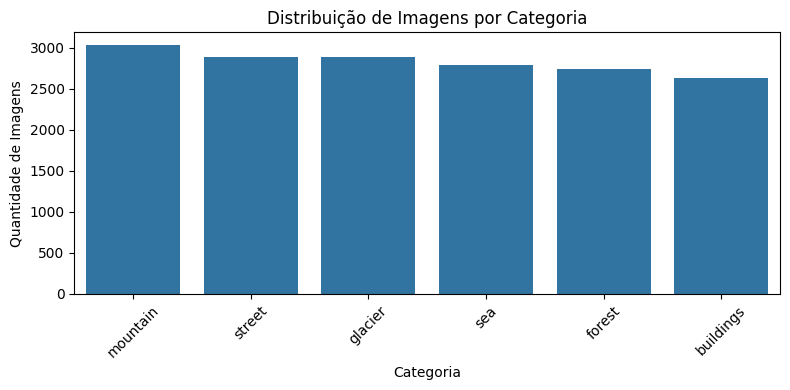

In [ ]:
### Distribuição das imagens nas 6 categorias
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.title("Distribuição de Imagens por Categoria")
plt.xticks(rotation=45)
plt.xlabel("Categoria")
plt.ylabel("Quantidade de Imagens")
plt.tight_layout()
plt.show()

### **4. SEPARAÇÃO DA BASE EM TREINO E TESTE**

In [ ]:
# Separação entre treino e teste com base no caminho
df['type_dataset'] = df.full_path.apply(lambda x: x.split('/')[-3])
df['target'] = df.full_path.apply(lambda x: x.split('/')[-2])
df['file_name'] = df.full_path.apply(lambda x: x.split('/')[-1])
df['extension'] = df.full_path.apply(lambda x: x.split('.')[-1])

train_df = df[df['type_dataset'] == 'train']
test_df = df[df['type_dataset'] == 'test']

print(f'Tamanho do conjunto de treino: {len(train_df)}')
print(f'Tamanho do conjunto de teste: {len(test_df)}')

### **5. TRANSFORMANDO IMAGENS EM ARRAY E SEPARANDO X E Y CONFORME O MODELO**

In [ ]:
from keras.utils import load_img, img_to_array

In [ ]:
def resize_convert_to_array(full_path, img_size=(64, 64)):
  return img_to_array(load_img(full_path,).resize(img_size)) / 256

In [ ]:
from tqdm import tqdm

df = df.sample(frac=1, random_state=42)
df.reset_index(drop=True, inplace=True)

In [ ]:
imgs = []
targets = []

for line in tqdm(df.itertuples(), total=df.shape[0]):
    try:
        img_processed = resize_convert_to_array(line.full_path)
        if img_processed is not None:
            imgs.append(img_processed)
            targets.append(line.label)
    except Exception as e:
        print(f"Erro ao processar a imagem: {line.full_path}. Erro: {e}")
        continue  # Pula para próxima imagem

  0%|          | 36/16987 [00:00<00:47, 356.49it/s]

Erro ao processar a imagem: /content/drive/MyDrive/02 - Colab Notebooks - Data Science/Python/MBA Fia Labdata - Data Science e Inteligência Artificial/02. Inteligência Artificial II - Prof Carlos Beluzo/6 - Projeto Deep Learning/4 - Projeto_06/Base_de_dados_Projeto06/base_classificacao-imagem-tipos-cenarios-pelo-mundo/train/sea/2137.jpg. Erro: cannot identify image file <_io.BytesIO object at 0x79c0d762f7e0>


  1%|          | 138/16987 [00:01<02:53, 97.10it/s]

Erro ao processar a imagem: /content/drive/MyDrive/02 - Colab Notebooks - Data Science/Python/MBA Fia Labdata - Data Science e Inteligência Artificial/02. Inteligência Artificial II - Prof Carlos Beluzo/6 - Projeto Deep Learning/4 - Projeto_06/Base_de_dados_Projeto06/base_classificacao-imagem-tipos-cenarios-pelo-mundo/train/sea/2086.jpg. Erro: cannot identify image file <_io.BytesIO object at 0x79c0d710bfb0>


  8%|▊         | 1377/16987 [00:04<00:43, 360.21it/s]

...

 20%|██        | 3455/16987 [00:10<00:32, 413.44it/s]

Erro ao processar a imagem: /content/drive/MyDrive/02 - Colab Notebooks - Data Science/Python/MBA Fia Labdata - Data Science e Inteligência Artificial/02. Inteligência Artificial II - Prof Carlos Beluzo/6 - Projeto Deep Learning/4 - Projeto_06/Base_de_dados_Projeto06/base_classificacao-imagem-tipos-cenarios-pelo-mundo/train/sea/21.jpg. Erro: cannot identify image file <_io.BytesIO object at 0x79c0d710bfb0>


 97%|█████████▋| 16553/16987 [1:07:16<05:24,  1.34it/s]

Erro ao processar a imagem: /content/drive/MyDrive/02 - Colab Notebooks - Data Science/Python/MBA Fia Labdata - Data Science e Inteligência Artificial/02. Inteligência Artificial II - Prof Carlos Beluzo/6 - Projeto Deep Learning/4 - Projeto_06/Base_de_dados_Projeto06/base_classificacao-imagem-tipos-cenarios-pelo-mundo/train/sea/2148.jpg. Erro: cannot identify image file <_io.BytesIO object at 0x79c0d77a8c20>


100%|██████████| 16987/16987 [1:12:02<00:00,  3.93it/s]


In [ ]:
# Cria um novo DataFrame apenas com as imagens válidas
df_processed = pd.DataFrame({
    'image_array': imgs,
    'label': targets
})

df_processed.head(10)

,image_array,label
0,"[[[0.19921875, 0.1484375, 0.11328125], [0.2460...",street
1,"[[[0.109375, 0.1953125, 0.30859375], [0.183593...",glacier
2,"[[[0.74609375, 0.8671875, 0.98046875], [0.7460...",glacier
3,"[[[0.28515625, 0.4765625, 0.7578125], [0.26562...",buildings
4,"[[[0.35546875, 0.5625, 0.7734375], [0.3671875,...",glacier
5,"[[[0.32421875, 0.51953125, 0.75], [0.328125, 0...",mountain
6,"[[[0.64453125, 0.78515625, 0.92578125], [0.648...",sea
7,"[[[0.24609375, 0.2421875, 0.2265625], [0.34375...",forest
8,"[[[0.08203125, 0.08984375, 0.08984375], [0.113...",forest
9,"[[[0.33984375, 0.3671875, 0.43359375], [0.2929...",glacier


### **5.1. SALVANDO df_processed.to_csv NO DRIVE (Ler esse arquivo a partir de então)**

In [ ]:
# Caminho para salvar no seu Drive
caminho_csv = (r"/content/drive/MyDrive/02 - Colab Notebooks - Data Science/Python/MBA Fia Labdata - Data Science e Inteligência Artificial/02. Inteligência Artificial II - Prof Carlos Beluzo/6 - Projeto Deep Learning/4 - Projeto_06/imagens_processadas.csv")

# Transformar array de imagens em uma lista de strings (para salvar no CSV)
df_processed['image_array'] = df_processed['image_array'].apply(lambda x: np.array(x).flatten().tolist())

# Salvar o DataFrame
df_processed.to_csv(caminho_csv, index=False)
print("CSV salvo com sucesso em:", caminho_csv)

### **5.2 CARREGANDO ARRAY DO AQUIVO .CSV DIRETO DO DRIVE**

In [ ]:
# Carregar o CSV
df_processed = pd.read_csv((r"/content/drive/MyDrive/02 - Colab Notebooks - Data Science/Python/MBA Fia Labdata - Data Science e Inteligência Artificial/02. Inteligência Artificial II - Prof Carlos Beluzo/6 - Projeto Deep Learning/4 - Projeto_06/imagens_processadas.csv"))

# Converter de string para array numpy novamente
X = np.array([np.fromstring(img_str[1:-1], sep=',') for img_str in df_processed['image_array']])
y = df_processed['label'].values

In [ ]:
from sklearn.model_selection import train_test_split

# Divide entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((13584, 12288), (13584,), (3397, 12288), (3397,))

In [ ]:
#Codificando em números os labels das imagens
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

label_encoder.fit(np.unique(np.concatenate([y_train, y_test])))

y_train_encoder = label_encoder.transform(y_train)
y_test_encoder = label_encoder.transform(y_test)

y_test_encoder.shape

(3397,)

In [ ]:
#Verificando se a base abrange todas as classificações
np.unique(np.concatenate([y_train, y_test]))

array(['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'],
      dtype=object)

In [ ]:
from keras.utils import to_categorical

y_train_categorical = to_categorical(y_train_encoder)
y_test_categorical = to_categorical(y_test_encoder)

y_test_categorical.shape

(3397, 6)

In [ ]:
input_shape = X_train[0].shape
input_shape

(12288,)

In [ ]:
y_train_categorical

array([[0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0.]])

In [ ]:
y_test_categorical

array([[0., 0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0.],
       ...,
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.]])

In [ ]:
y_test

array(['glacier', 'buildings', 'sea', ..., 'street', 'street', 'street'],
      dtype=object)

### **6. CRIANDO A REDE NEURAL CONVOLUCIONAL**

In [ ]:
#Reshape de X_train e X_test
X_train = X_train.reshape(-1, 64, 64, 3)
X_test = X_test.reshape(-1, 64, 64, 3)

In [ ]:
#Definindo o input shape
input_shape = (64, 64, 3)

In [ ]:
# Primeira Rede Neural Convolucional

model_cnn1 = Sequential([
    Input(shape=input_shape),

    Conv2D(32, (3, 3), activation='relu', padding='same', name='conv_1', input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2), name='pooling_1'),

    Conv2D(32, (3, 3), activation='relu', padding='same', name='conv_2'),
    MaxPooling2D((2, 2), name='pooling_2'),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(6, activation='softmax')
])

model_cnn1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Treinamento do Modelo
history_cnn1 = model_cnn1.fit(X_train,
                    y_train_categorical,
                    epochs=50,
                    batch_size=128,
                    validation_data=(X_test, y_test_categorical))

model_cnn1.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.4799 - loss: 1.2986 - val_accuracy: 0.6718 - val_loss: 0.8792
Epoch 2/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6976 - loss: 0.8281 - val_accuracy: 0.7374 - val_loss: 0.7367
Epoch 3/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7418 - loss: 0.7066 - val_accuracy: 0.7557 - val_loss: 0.6768
Epoch 4/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7779 - loss: 0.6169 - val_accuracy: 0.6238 - val_loss: 0.9589
Epoch 5/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7856 - loss: 0.5676 - val_accuracy: 0.7551 - val_loss: 0.6581
Epoch 6/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8303 - loss: 0.4808 - val_accuracy: 0.7563 - val_loss: 0.6929
Epoch 7/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8467 - loss: 0.4403 - val_accuracy: 0.7539 - val_loss: 0.6985
Epoch 8/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8601 - loss: 0.3919 - val_accuracy: 0

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_1 (MaxPooling2D)        │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_2 (MaxPooling2D)        │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,178,868 (12.13 MB)

 Trainable params: 1,059,622 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,119,246 (8.08 MB)

In [ ]:
# Avaliação final da primeira rede CNN
loss, accuracy = model_cnn1.evaluate(X_test, y_test_categorical)
print(f"Acurácia CNN 1: {accuracy:.4f} | Loss CNN 1: {loss:.4f}")

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7944 - loss: 1.2336
Acurácia CNN 1: 0.7951 | Loss CNN 1: 1.2776


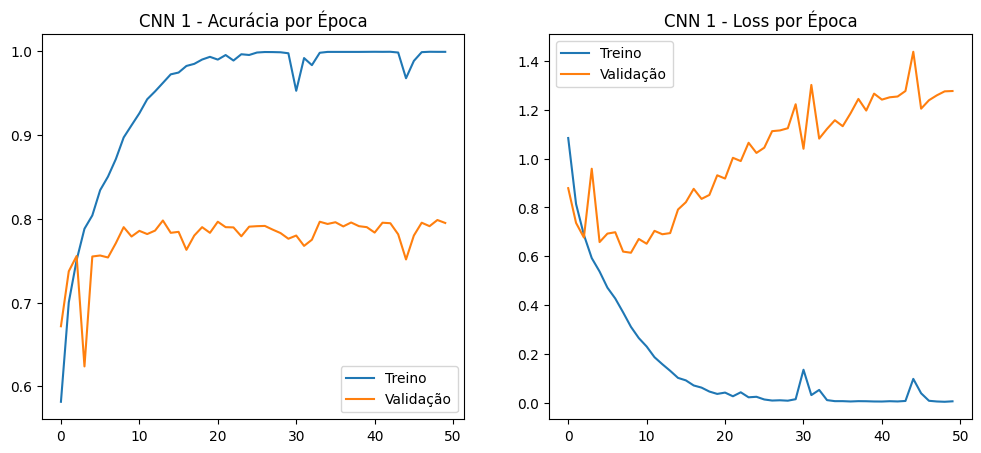

In [ ]:
# Curvas de perda e acurácia
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_cnn1.history['accuracy'], label='Treino')
plt.plot(history_cnn1.history['val_accuracy'], label='Validação')
plt.title('CNN 1 - Acurácia por Época')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_cnn1.history['loss'], label='Treino')
plt.plot(history_cnn1.history['val_loss'], label='Validação')
plt.title('CNN 1 - Loss por Época')
plt.legend()
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(np.unique(np.concatenate([y_train, y_test])))

LabelEncoder()

In [ ]:
# Obtemos as previsões do modelo no conjunto de teste (executar nas 3 redes)
y_pred_probs = model_cnn1.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs_cnn1, axis=1)

from sklearn.metrics import classification_report

print(classification_report(
    y_test_encoder,
    y_pred_classes,
    target_names=label_encoder.classes_
))

107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

   buildings       0.76      0.74      0.75       505
      forest       0.96      0.90      0.93       557
     glacier       0.74      0.74      0.74       579
    mountain       0.75      0.78      0.77       635
         sea       0.79      0.77      0.78       568
      street       0.78      0.84      0.81       553

    accuracy                           0.80      3397
   macro avg       0.80      0.80      0.80      3397
weighted avg       0.80      0.80      0.80      3397



In [ ]:
label_encoder = LabelEncoder()
label_encoder.fit(np.unique(np.concatenate([y_train, y_test])))

y_train_encoder = label_encoder.transform(y_train)
y_test_encoder = label_encoder.transform(y_test)

In [ ]:
# Cria um DataFrame com os resultados de teste
df_resultados = pd.DataFrame({
    'true_label': label_encoder.inverse_transform(y_test_encoder),
    'predicted_label': label_encoder.inverse_transform(y_pred_classes), # Use y_pred_classes instead of predicted_labels
    'confidence': np.max(y_pred_probs_cnn1, axis=1)
})

# Visualiza as 10 primeiras linhas
df_resultados.head(10)

,true_label,predicted_label,confidence
0,glacier,glacier,0.987315
1,buildings,buildings,0.998597
2,sea,sea,0.662270
3,sea,sea,0.998325
4,sea,sea,0.999305
5,street,street,1.000000
6,mountain,mountain,0.999725
7,forest,forest,0.993605
8,sea,sea,0.999684
9,glacier,glacier,0.999876


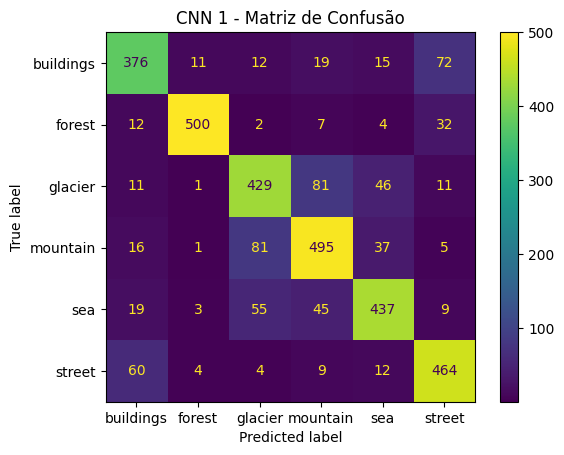

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test_encoder, y_pred_classes_cnn1, display_labels=label_encoder.classes_)
plt.title("CNN 1 - Matriz de Confusão")
plt.show()

In [ ]:
print(df_processed['label'].value_counts())

label
mountain     3037
street       2893
glacier      2890
sea          2788
forest       2745
buildings    2628
Name: count, dtype: int64


In [ ]:
from keras_visualizer import visualizer
from IPython.display import Image

# Esquema CNN 1
visualizer(model_cnn1, file_name='cnn1_model', file_format='png')

Image('cnn1_model.png')

### **7. CONSIDERAÇÕES DE MELHORIAS PARA A REDE NEURAL CONVOLUCIONAL**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',       # ou 'val_accuracy', se preferir
    patience=5,               # número de épocas sem melhoria antes de parar
    restore_best_weights=True
)

In [ ]:
# Melhorando a Rede Neural Convolucional

model = Sequential([
    Input(shape=input_shape),

    Conv2D(128, (3, 3), activation='relu', padding='same', name='conv_1', input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2), name='pooling_1'),

    Conv2D(64, (3, 3), activation='relu', padding='same', name='conv_2'),
    MaxPooling2D((2, 2), name='pooling_2'),

    Conv2D(32, (3, 3), activation='relu', padding='same', name='conv_3'),
    MaxPooling2D((2, 2), name='pooling_3'),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(6, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Treinamento do Modelo
history = model.fit(X_train,
                    y_train_categorical,
                    epochs=50,
                    batch_size=128,
                    validation_data=(X_test, y_test_categorical),
                    callbacks=[early_stop])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.4313 - loss: 1.4002 - val_accuracy: 0.6491 - val_loss: 0.9338
Epoch 2/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6473 - loss: 0.9391 - val_accuracy: 0.6894 - val_loss: 0.8462
Epoch 3/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6940 - loss: 0.8475 - val_accuracy: 0.6771 - val_loss: 0.8555
Epoch 4/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7165 - loss: 0.7639 - val_accuracy: 0.7368 - val_loss: 0.7183
Epoch 5/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7538 - loss: 0.6809 - val_accuracy: 0.7677 - val_loss: 0.6318
Epoch 6/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7861 - loss: 0.6004 - val_accuracy: 0.7954 - val_loss: 0.5785
Epoch 7/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8018 - loss: 0.5497 - val_accuracy: 0.8001 - val_loss: 0.5661
Epoch 8/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8065 - loss: 0.5402 - val_accu

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 64, 64, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_1 (MaxPooling2D)        │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_2 (MaxPooling2D)        │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_3 (MaxPooling2D)        │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,076,660 (4.11 MB)

 Trainable params: 358,886 (1.37 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 717,774 (2.74 MB)

In [ ]:
# Avaliação final da primeira rede CNN
loss, accuracy = model.evaluate(X_test, y_test_categorical)
print(f"Acurácia CNN 2 : {accuracy:.4f} | Loss CNN 2: {loss:.4f}")

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8373 - loss: 0.4834
Acurácia CNN 2 : 0.8287 | Loss CNN 2: 0.4962


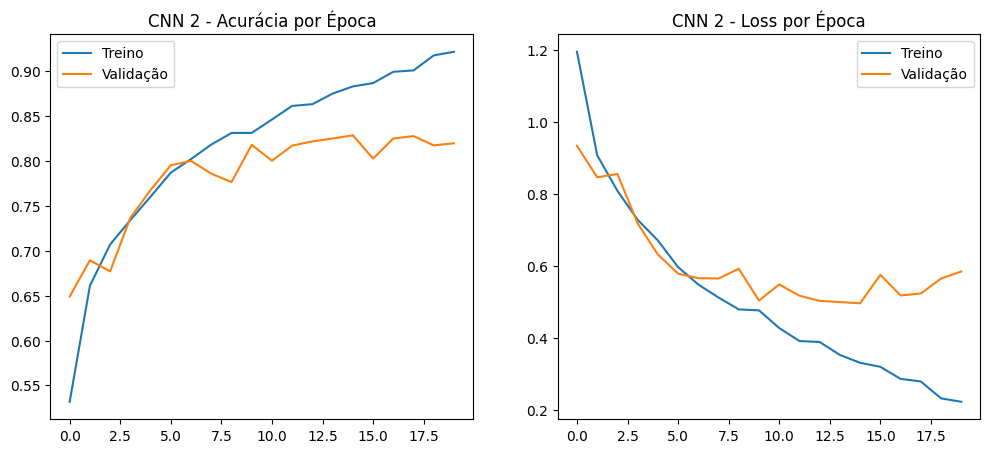

In [ ]:
# Curvas de perda e acurácia
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('CNN 2 - Acurácia por Época')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('CNN 2 - Loss por Época')
plt.legend()
plt.show()

In [ ]:
# Obtemos as previsões do modelo no conjunto de teste (executar nas 3 redes)
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs_cnn2, axis=1)

from sklearn.metrics import classification_report

print(classification_report(
    y_test_encoder,
    y_pred_classes,
    target_names=label_encoder.classes_
))

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

   buildings       0.84      0.78      0.81       505
      forest       0.97      0.92      0.94       557
     glacier       0.78      0.79      0.78       579
    mountain       0.75      0.82      0.78       635
         sea       0.87      0.79      0.82       568
      street       0.81      0.88      0.84       553

    accuracy                           0.83      3397
   macro avg       0.83      0.83      0.83      3397
weighted avg       0.83      0.83      0.83      3397



In [ ]:
label_encoder = LabelEncoder()
label_encoder.fit(np.unique(np.concatenate([y_train, y_test])))

y_train_encoder = label_encoder.transform(y_train)
y_test_encoder = label_encoder.transform(y_test)

In [ ]:
# Cria um DataFrame com os resultados de teste
df_resultados = pd.DataFrame({
    'true_label': label_encoder.inverse_transform(y_test_encoder),
    'predicted_label': label_encoder.inverse_transform(y_pred_classes), # Use y_pred_classes instead of predicted_labels
    'confidence': np.max(y_pred_probs_cnn2, axis=1)
})

# Visualiza as 10 primeiras linhas
df_resultados.head(10)

,true_label,predicted_label,confidence
0,glacier,glacier,0.891498
1,buildings,buildings,0.852882
2,sea,sea,0.952589
3,sea,sea,0.990834
4,sea,sea,0.931374
5,street,street,0.999019
6,mountain,mountain,0.980233
7,forest,forest,0.999800
8,sea,sea,0.985865
9,glacier,glacier,0.706203


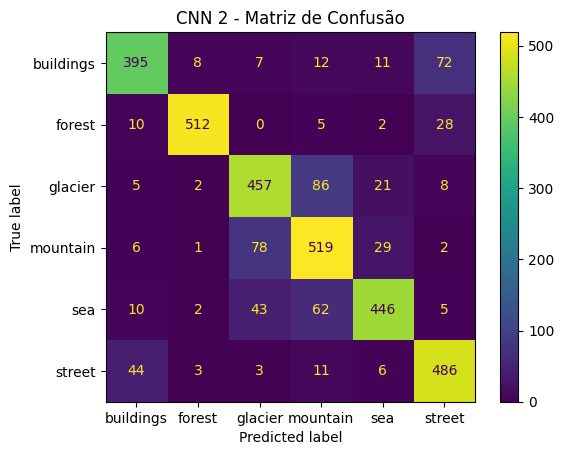

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test_encoder, y_pred_classes, display_labels=label_encoder.classes_)
plt.title("CNN 2 - Matriz de Confusão")
plt.show()

In [ ]:
print(df_processed['label'].value_counts())

label
mountain     3037
street       2893
glacier      2890
sea          2788
forest       2745
buildings    2628
Name: count, dtype: int64


In [ ]:
# Esquema CNN 2
visualizer(model_cnn1, file_name='cnn2_model', file_format='png')

Image('cnn2_model.png')

In [ ]:
from PIL import Image

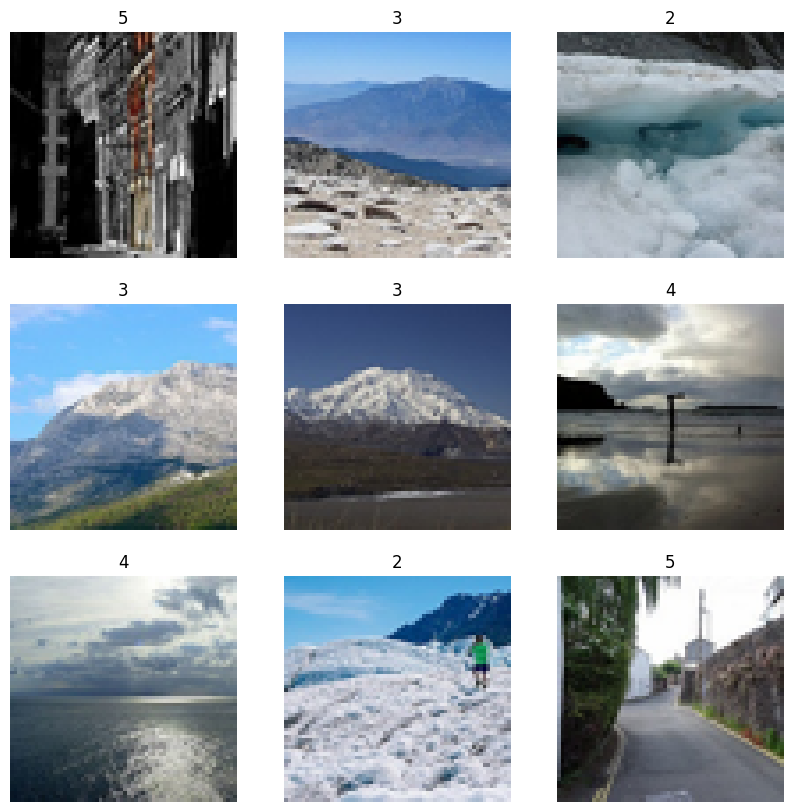

In [ ]:
# Visualizando algumas imagens normalizadas
def plot_images(images, labels):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i])
        plt.title(labels[i])
        plt.axis('off')
    plt.show()

    # Correção: fechando o parêntese
plot_images(X_train, np.argmax(y_train_categorical, axis=1))

## **8. CRIANDO A REDE NEURAL DENSA COM FLATTEN**

In [ ]:
#Aplicar EarlyStopping ao treinamento da nova rede
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [ ]:
#Construir uma Rede Densa (DNN) com Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

model_dnn = Sequential([
    Input(shape=input_shape),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(6, activation='softmax')
])

model_dnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_dnn = model_dnn.fit(
    X_train, y_train_categorical,
    epochs=50,
    batch_size=128,
    validation_data=(X_test, y_test_categorical),
    callbacks=[early_stop]
)

Epoch 1/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 13s 95ms/step - accuracy: 0.2241 - loss: 2.4852 - val_accuracy: 0.4292 - val_loss: 1.4548
Epoch 2/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3834 - loss: 1.5122 - val_accuracy: 0.4710 - val_loss: 1.4291
Epoch 3/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4058 - loss: 1.4568 - val_accuracy: 0.5037 - val_loss: 1.3572
Epoch 4/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4198 - loss: 1.4145 - val_accuracy: 0.4946 - val_loss: 1.3988
Epoch 5/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4382 - loss: 1.3874 - val_accuracy: 0.5075 - val_loss: 1.3383
Epoch 6/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3984 - loss: 1.4579 - val_accuracy: 0.4984 - val_loss: 1.3674
Epoch 7/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4396 - loss: 1.4135 - val_accuracy: 0.4672 - val_loss: 1.4040
Epoch 8/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4547 - loss: 1.3678 - val_accuracy: 

In [ ]:
loss_dnn, acc_dnn = model_dnn.evaluate(X_test, y_test_categorical)
print(f"DNN - Acurácia: {acc_dnn:.4f} | DNN - Loss: {loss_dnn:.4f}")

107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5377 - loss: 1.2726
DNN - Acurácia: 0.5316 | DNN - Loss: 1.2659


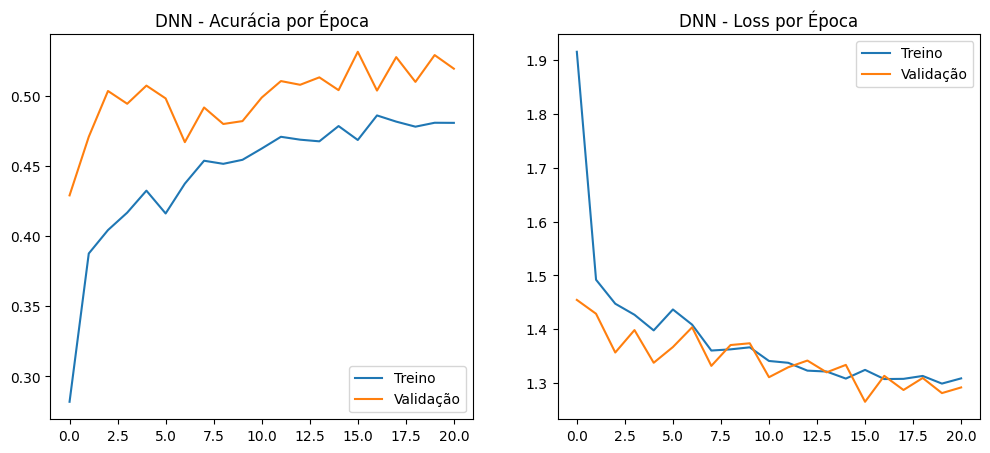

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_dnn.history['accuracy'], label='Treino')
plt.plot(history_dnn.history['val_accuracy'], label='Validação')
plt.title('DNN - Acurácia por Época')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_dnn.history['loss'], label='Treino')
plt.plot(history_dnn.history['val_loss'], label='Validação')
plt.title('DNN - Loss por Época')
plt.legend()
plt.show()

In [ ]:
y_pred_probs_dnn = model_dnn.predict(X_test)
y_pred_classes_dnn = np.argmax(y_pred_probs_dnn, axis=1)

print(classification_report(
    y_test_encoder,
    y_pred_classes_dnn,
    target_names=label_encoder.classes_
))

107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
              precision    recall  f1-score   support

   buildings       0.34      0.22      0.27       505
      forest       0.76      0.72      0.74       557
     glacier       0.53      0.63      0.58       579
    mountain       0.63      0.54      0.58       635
         sea       0.36      0.24      0.28       568
      street       0.49      0.81      0.61       553

    accuracy                           0.53      3397
   macro avg       0.52      0.53      0.51      3397
weighted avg       0.52      0.53      0.51      3397



In [ ]:
label_encoder = LabelEncoder()
label_encoder.fit(np.unique(np.concatenate([y_train, y_test])))

y_train_encoder = label_encoder.transform(y_train)
y_test_encoder = label_encoder.transform(y_test)

In [ ]:
# Cria um DataFrame com os resultados de teste
df_resultados = pd.DataFrame({
    'true_label': label_encoder.inverse_transform(y_test_encoder),
    'predicted_label': label_encoder.inverse_transform(y_pred_classes), # Use y_pred_classes instead of predicted_labels
    'confidence': np.max(y_pred_probs_dnn, axis=1)
})

# Visualiza as 10 primeiras linhas
df_resultados.head(10)

,true_label,predicted_label,confidence
0,glacier,glacier,0.252894
1,buildings,buildings,0.240794
2,sea,sea,0.233890
3,sea,sea,0.275903
4,sea,sea,0.437964
5,street,street,0.688022
6,mountain,mountain,0.337007
7,forest,forest,0.454148
8,sea,sea,0.218353
9,glacier,glacier,0.384813


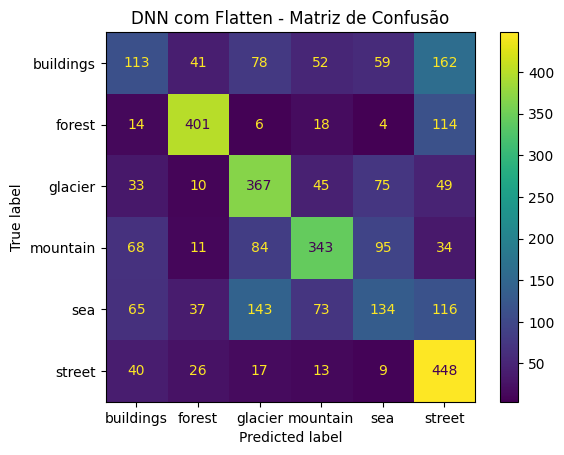

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test_encoder, y_pred_classes_dnn, display_labels=label_encoder.classes_)
plt.title("DNN com Flatten - Matriz de Confusão")
plt.show()


## **9. ILUSTRAÇÕES DAS REDES**

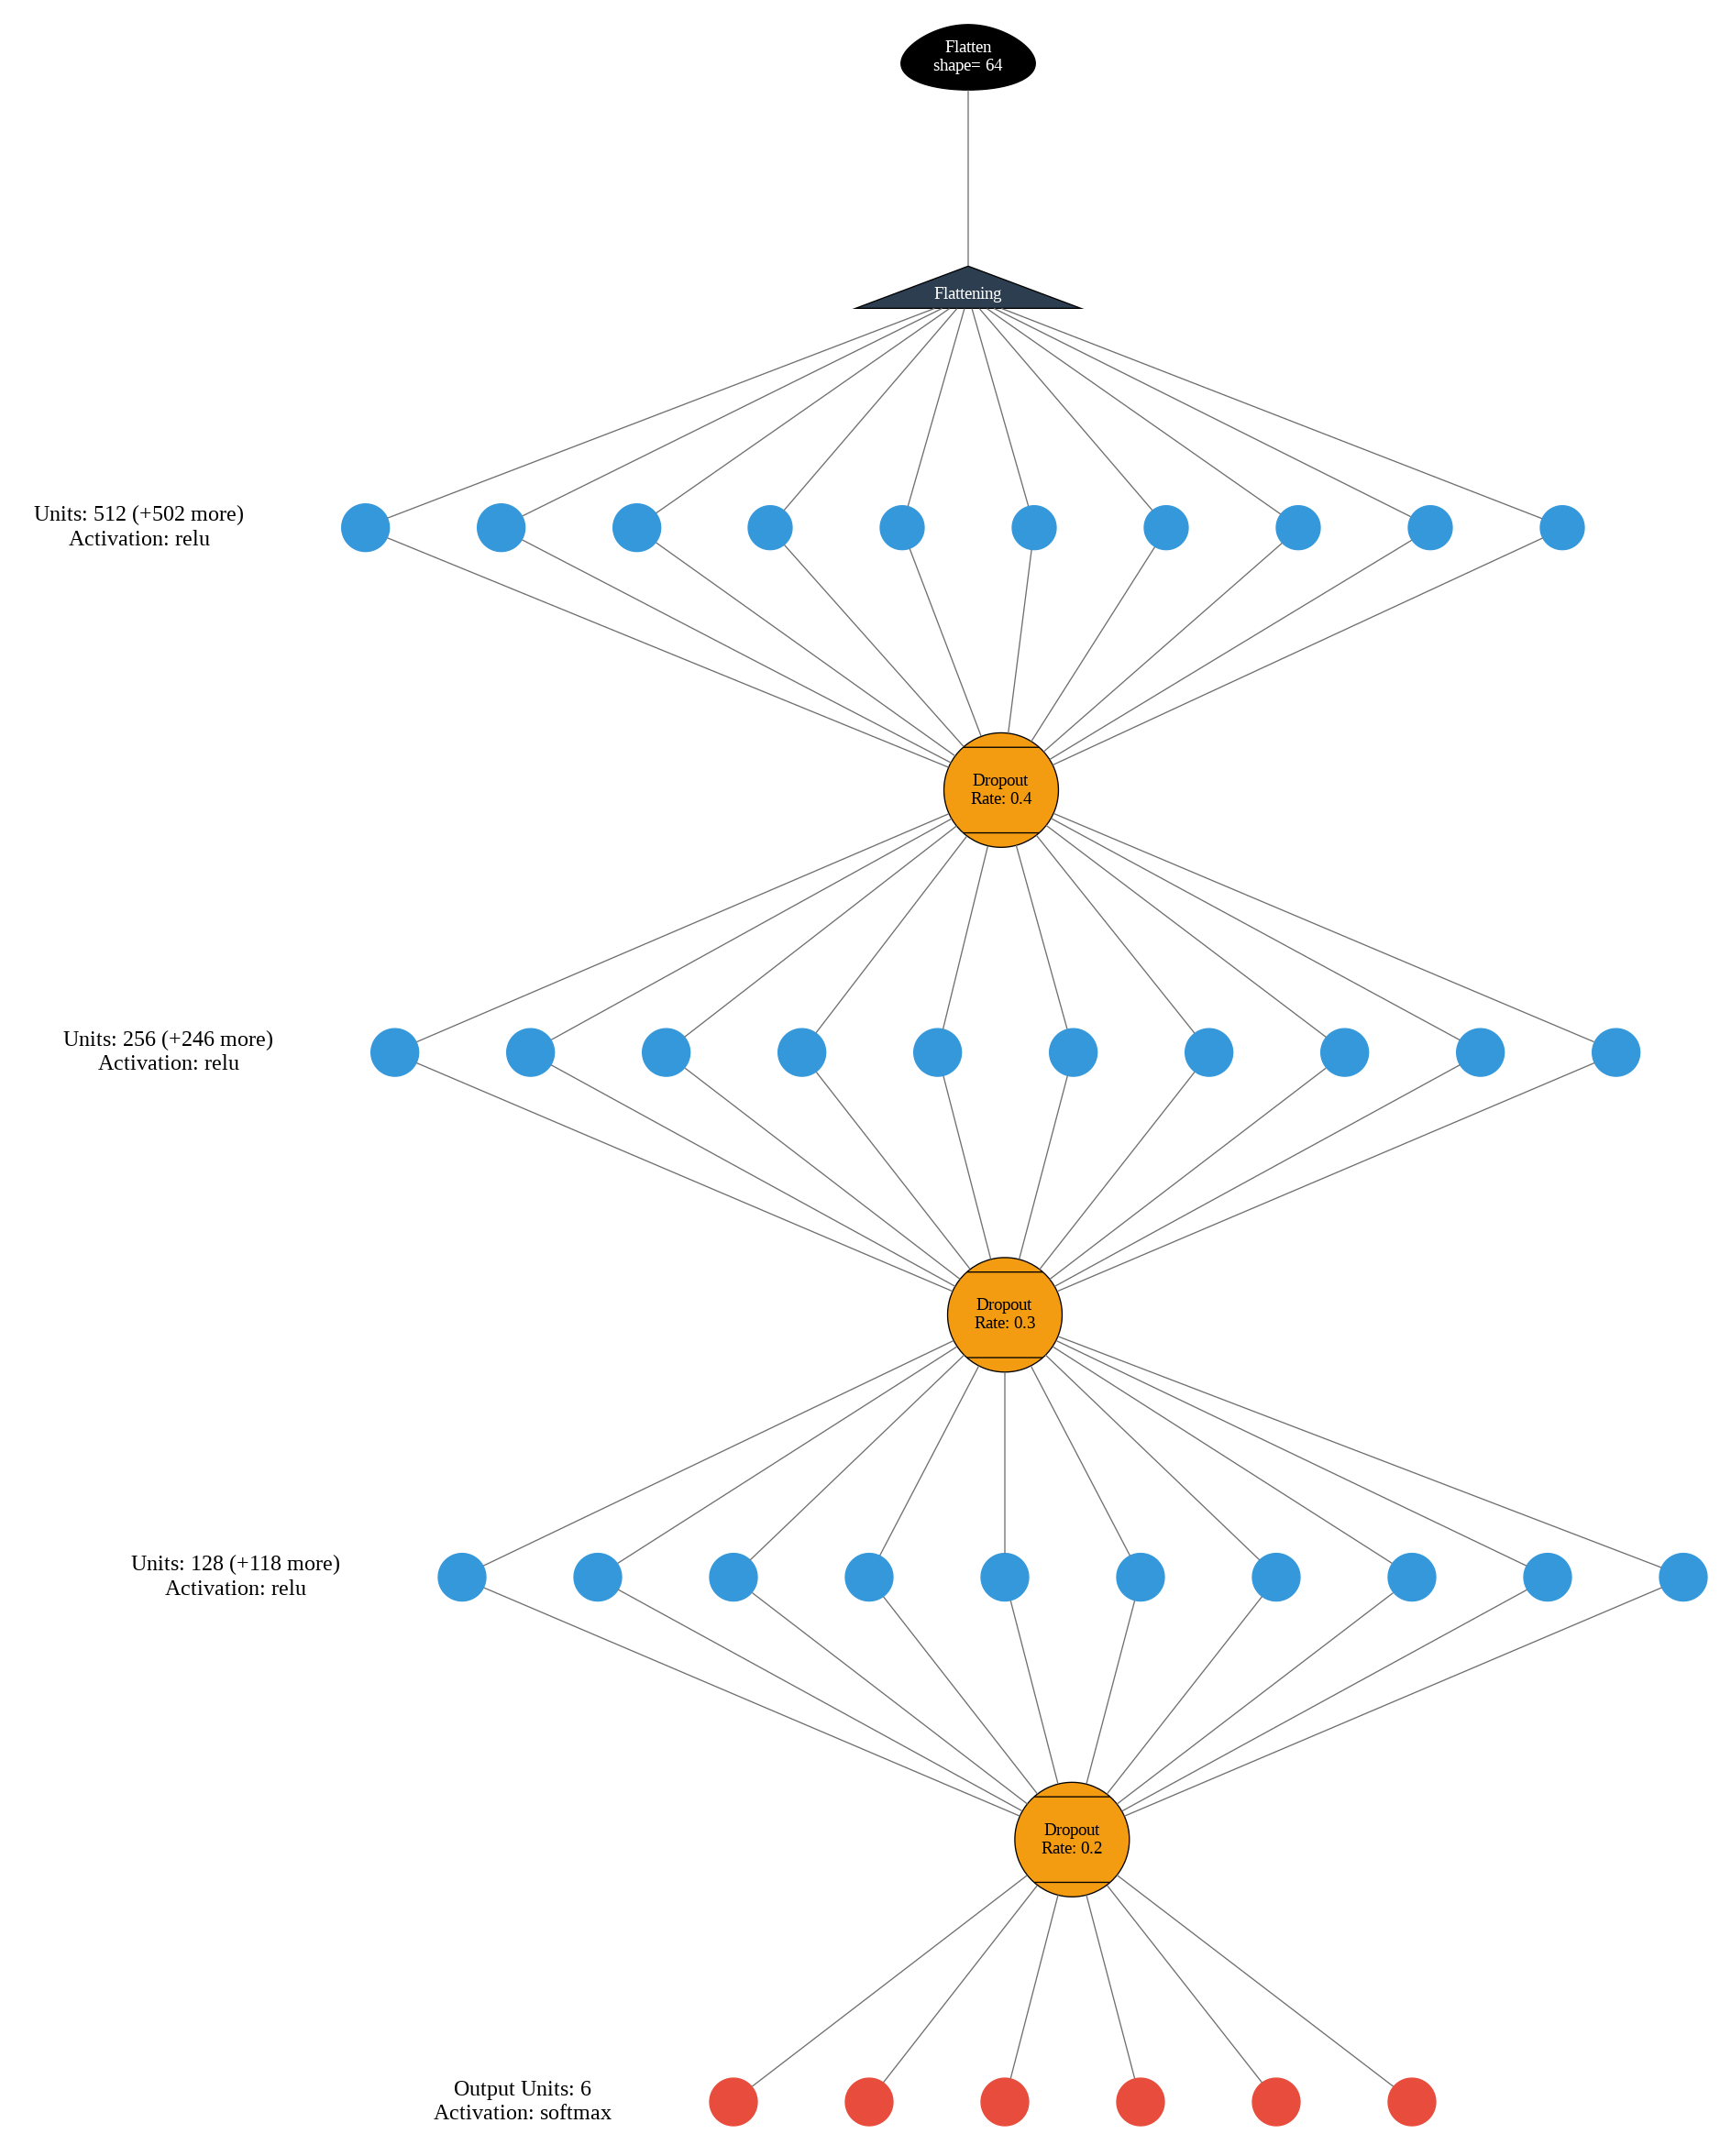

In [ ]:
# Esquema DNN
visualizer(model_dnn, file_name='dnn_model', file_format='png')

Image('dnn_model.png')

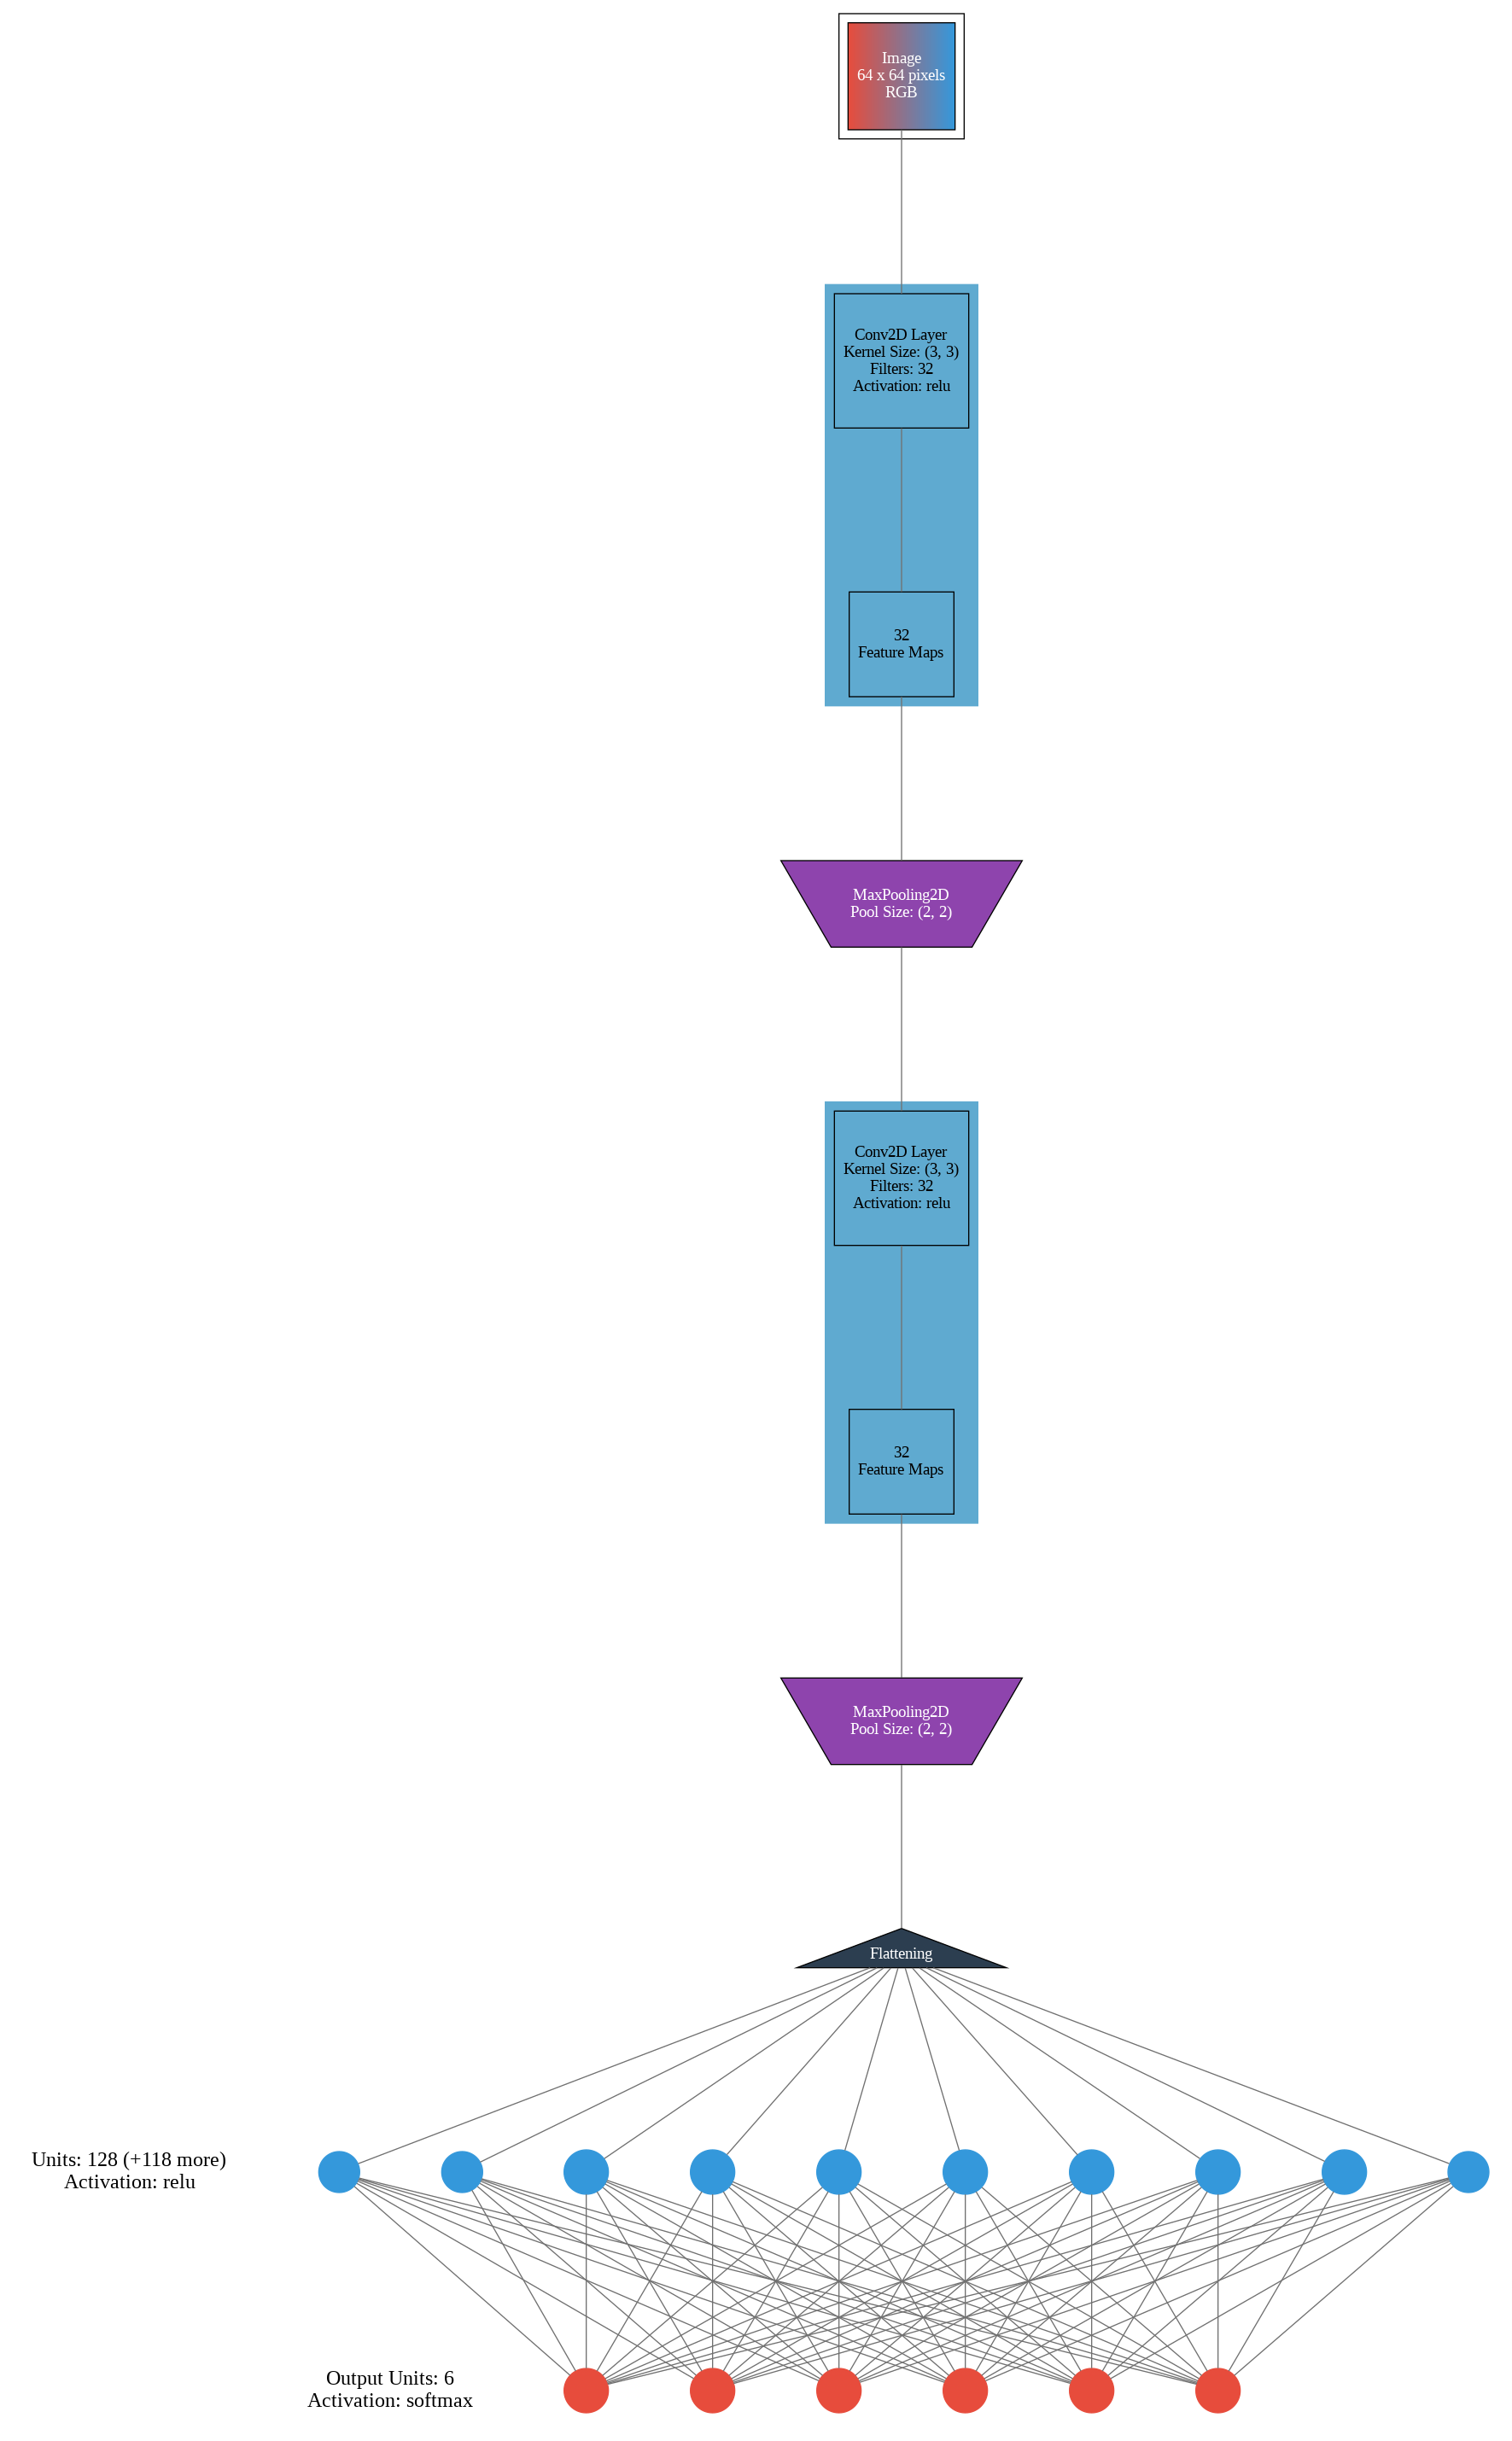

In [ ]:
# Esquema CNN 1
visualizer(model_cnn1, file_name='cnn1_model', file_format='png')

Image('cnn1_model.png')

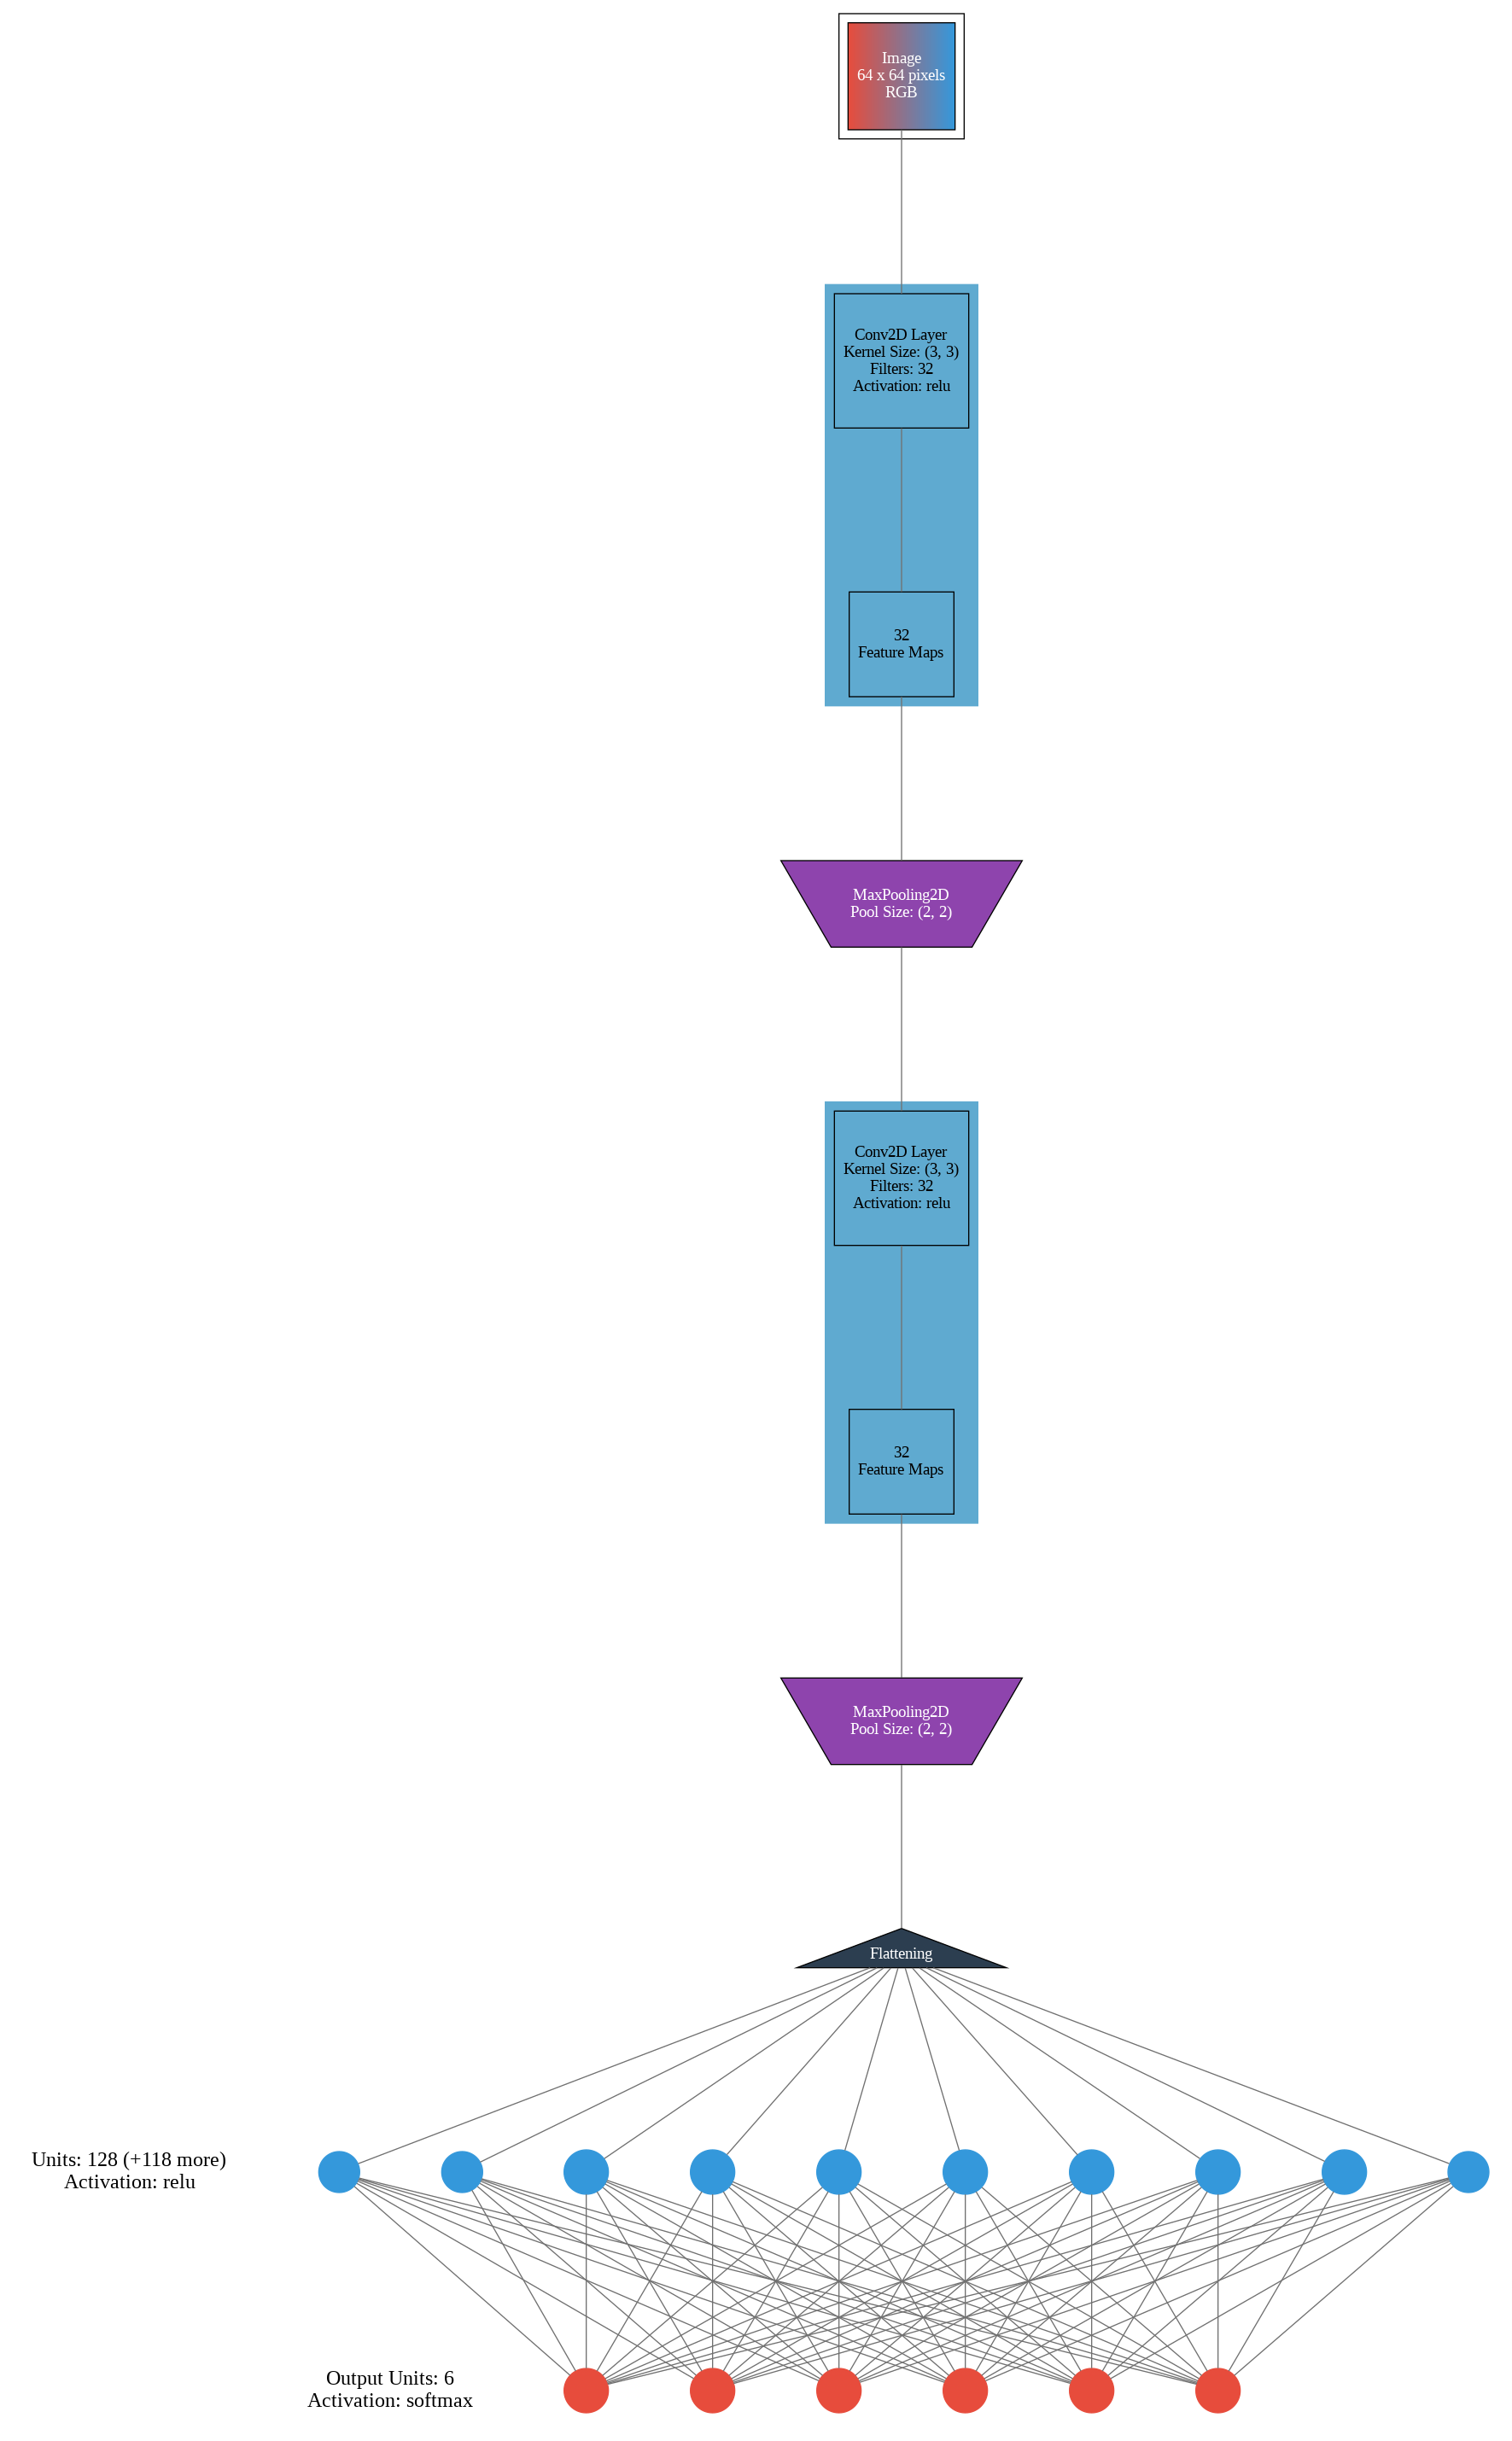

In [ ]:
# Esquema CNN 2
visualizer(model_cnn1, file_name='cnn2_model', file_format='png')

Image('cnn2_model.png')

<ipython-input-95-1799755804>:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('viridis', n_layers)


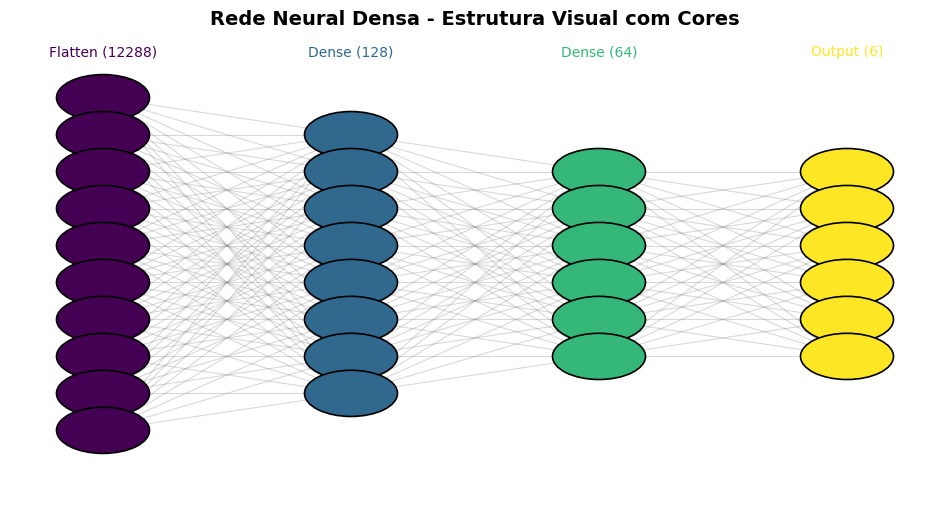

In [ ]:
from matplotlib import cm

def draw_neural_net(ax, left, right, bottom, top, layer_sizes, layer_labels=None):
    n_layers = len(layer_sizes)
    v_spacing = (top - bottom) / float(max(layer_sizes))
    h_spacing = (right - left) / float(n_layers - 1)

    # Paleta de cores para camadas
    colors = cm.get_cmap('viridis', n_layers)

    # Neurônios
    neuron_positions = {}
    for i in range(n_layers):
        layer_top = v_spacing * (layer_sizes[i] - 1) / 2. + (top + bottom) / 2.
        for j in range(layer_sizes[i]):
            x = left + i * h_spacing
            y = layer_top - j * v_spacing
            neuron_positions[(i, j)] = (x, y)
            circle = plt.Circle((x, y), 0.05, color=colors(i), ec='k', lw=1.2, zorder=4)
            ax.add_artist(circle)

        # Nome da camada
        if layer_labels:
            ax.text(x, top + 0.05, layer_labels[i], fontsize=10, ha='center', color=colors(i))

    # Conexões
    for i in range(n_layers - 1):
        for a in range(layer_sizes[i]):
            for b in range(layer_sizes[i+1]):
                x1, y1 = neuron_positions[(i, a)]
                x2, y2 = neuron_positions[(i+1, b)]
                line = plt.Line2D([x1, x2], [y1, y2], c='gray', alpha=0.3, lw=0.8)
                ax.add_artist(line)

# Exemplo de estrutura reduzida
layer_sizes = [10, 8, 6, 6]
layer_labels = ['Flatten (12288)', 'Dense (128)', 'Dense (64)', 'Output (6)']

fig = plt.figure(figsize=(12, 6))
ax = fig.gca()
ax.axis('off')
draw_neural_net(ax, .1, .9, .1, .9, layer_sizes, layer_labels=layer_labels)
plt.title("Rede Neural Densa - Estrutura Visual com Cores", fontsize=14, weight='bold')
plt.show()

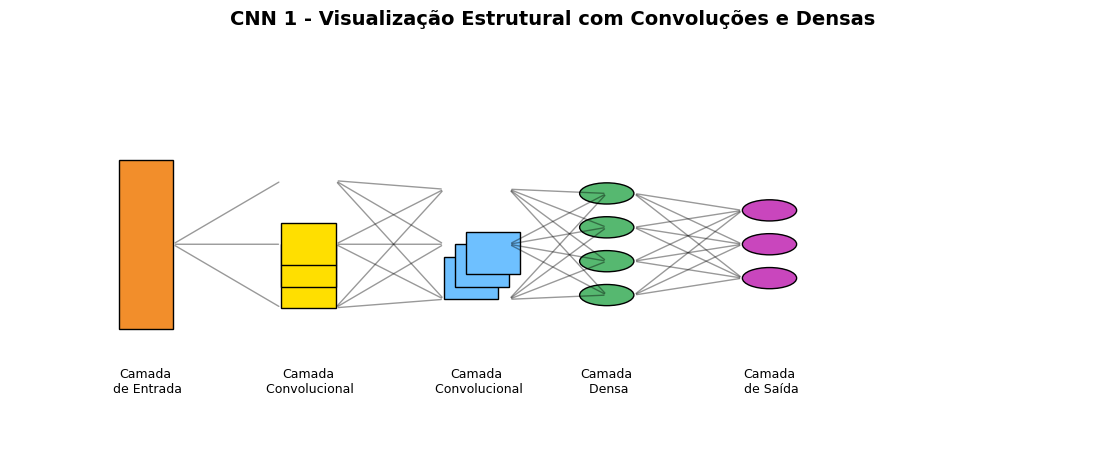

In [ ]:
from matplotlib.patches import Rectangle, Circle, FancyArrowPatch

def plot_cnn_structure():
    fig, ax = plt.subplots(figsize=(14, 5.5))
    ax.axis('off')

    # Posição das camadas
    x_positions = [0.1, 0.25, 0.4, 0.55, 0.7]
    y_center = 0.5

    # Camada de Entrada
    ax.add_patch(Rectangle((x_positions[0], y_center - 0.2), 0.05, 0.4, facecolor='#f28e2b', edgecolor='black'))
    ax.text(x_positions[0] + 0.025, y_center - 0.35, 'Camada\n de Entrada', ha='center', fontsize=9)

    # 1ª Camada Convolucional
    for i in range(3):
        ax.add_patch(Rectangle((x_positions[1], y_center - 0.15 + i*0.05), 0.05, 0.1, facecolor='#ffdf00', edgecolor='black'))
    ax.text(x_positions[1] + 0.025, y_center - 0.35, 'Camada\n Convolucional', ha='center', fontsize=9)

    # 2ª Camada Convolucional
    for i in range(3):
        ax.add_patch(Rectangle((x_positions[2] + i*0.01, y_center - 0.13 + i*0.03), 0.05, 0.1, facecolor='#6ec0ff', edgecolor='black'))
    ax.text(x_positions[2] + 0.03, y_center - 0.35, 'Camada\n Convolucional', ha='center', fontsize=9)

    # Camada Densa (círculos)
    for i in range(4):
        y = y_center + (i - 1.5) * 0.08
        ax.add_patch(Circle((x_positions[3], y), 0.025, facecolor='#56b870', edgecolor='black'))
    ax.text(x_positions[3], y_center - 0.35, 'Camada\n Densa', ha='center', fontsize=9)

    # Camada de Saída (círculos)
    for i in range(3):
        y = y_center + (i - 1) * 0.08
        ax.add_patch(Circle((x_positions[4], y), 0.025, facecolor='#c946bd', edgecolor='black'))
    ax.text(x_positions[4], y_center - 0.35, 'Camada\n de Saída', ha='center', fontsize=9)

    # Conexões com setas
    def draw_arrows(x1, y1_list, x2, y2_list):
        for y1 in y1_list:
            for y2 in y2_list:
                arrow = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='-', color='black', lw=1, alpha=0.4)
                ax.add_patch(arrow)

    # Entrada -> Conv1
    draw_arrows(x_positions[0] + 0.05, [y_center], x_positions[1], [y_center - 0.15, y_center, y_center + 0.15])

    # Conv1 -> Conv2
    draw_arrows(x_positions[1] + 0.05, [y_center - 0.15, y_center, y_center + 0.15],
                x_positions[2], [y_center - 0.13, y_center, y_center + 0.13])

    # Conv2 -> Densa
    draw_arrows(x_positions[2] + 0.06, [y_center - 0.13, y_center, y_center + 0.13],
                x_positions[3], [y_center + (i - 1.5) * 0.08 for i in range(4)])

    # Densa -> Saída
    draw_arrows(x_positions[3] + 0.025, [y_center + (i - 1.5) * 0.08 for i in range(4)],
                x_positions[4] - 0.025, [y_center + (i - 1) * 0.08 for i in range(3)])

    plt.title('CNN 1 - Visualização Estrutural com Convoluções e Densas', fontsize=14, weight='bold')
    plt.show()

# Chamar a função
plot_cnn_structure()

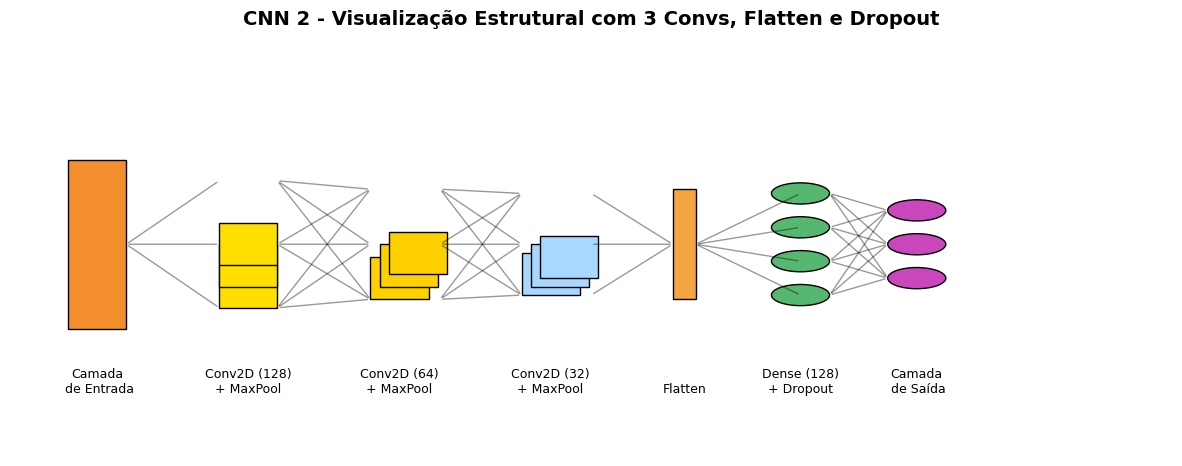

In [ ]:
from matplotlib.patches import Rectangle, Circle, FancyArrowPatch

def plot_cnn2_structure():
    fig, ax = plt.subplots(figsize=(15, 5.5))
    ax.axis('off')

    # Posições horizontais das camadas
    x_positions = [0.05, 0.18, 0.31, 0.44, 0.57, 0.68, 0.78]
    y_center = 0.5

    # Entrada
    ax.add_patch(Rectangle((x_positions[0], y_center - 0.2), 0.05, 0.4, facecolor='#f28e2b', edgecolor='black'))
    ax.text(x_positions[0] + 0.025, y_center - 0.35, 'Camada\n de Entrada', ha='center', fontsize=9)

    # Conv1
    for i in range(3):
        ax.add_patch(Rectangle((x_positions[1], y_center - 0.15 + i*0.05), 0.05, 0.1, facecolor='#ffdf00', edgecolor='black'))
    ax.text(x_positions[1] + 0.025, y_center - 0.35, 'Conv2D (128)\n+ MaxPool', ha='center', fontsize=9)

    # Conv2
    for i in range(3):
        ax.add_patch(Rectangle((x_positions[2] + i*0.008, y_center - 0.13 + i*0.03), 0.05, 0.1, facecolor='#ffd000', edgecolor='black'))
    ax.text(x_positions[2] + 0.025, y_center - 0.35, 'Conv2D (64)\n+ MaxPool', ha='center', fontsize=9)

    # Conv3
    for i in range(3):
        ax.add_patch(Rectangle((x_positions[3] + i*0.008, y_center - 0.12 + i*0.02), 0.05, 0.1, facecolor='#a8d8ff', edgecolor='black'))
    ax.text(x_positions[3] + 0.025, y_center - 0.35, 'Conv2D (32)\n+ MaxPool', ha='center', fontsize=9)

    # Flatten
    ax.add_patch(Rectangle((x_positions[4], y_center - 0.13), 0.02, 0.26, facecolor='#f2a541', edgecolor='black'))
    ax.text(x_positions[4] + 0.01, y_center - 0.35, 'Flatten', ha='center', fontsize=9)

    # Dense + Dropout
    for i in range(4):
        y = y_center + (i - 1.5) * 0.08
        ax.add_patch(Circle((x_positions[5], y), 0.025, facecolor='#56b870', edgecolor='black'))
    ax.text(x_positions[5], y_center - 0.35, 'Dense (128)\n+ Dropout', ha='center', fontsize=9)

    # Output
    for i in range(3):
        y = y_center + (i - 1) * 0.08
        ax.add_patch(Circle((x_positions[6], y), 0.025, facecolor='#c946bd', edgecolor='black'))
    ax.text(x_positions[6], y_center - 0.35, 'Camada\n de Saída', ha='center', fontsize=9)

    # Conexões
    def draw_arrows(x1, y1_list, x2, y2_list):
        for y1 in y1_list:
            for y2 in y2_list:
                arrow = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='-', color='black', lw=1, alpha=0.4)
                ax.add_patch(arrow)

    # Entrada → Conv1
    draw_arrows(x_positions[0] + 0.05, [y_center], x_positions[1], [y_center - 0.15, y_center, y_center + 0.15])
    # Conv1 → Conv2
    draw_arrows(x_positions[1] + 0.05, [y_center - 0.15, y_center, y_center + 0.15],
                x_positions[2], [y_center - 0.13, y_center, y_center + 0.13])
    # Conv2 → Conv3
    draw_arrows(x_positions[2] + 0.06, [y_center - 0.13, y_center, y_center + 0.13],
                x_positions[3], [y_center - 0.12, y_center, y_center + 0.12])
    # Conv3 → Flatten
    draw_arrows(x_positions[3] + 0.06, [y_center - 0.12, y_center, y_center + 0.12],
                x_positions[4], [y_center])
    # Flatten → Dense
    draw_arrows(x_positions[4] + 0.02, [y_center], x_positions[5],
                [y_center + (i - 1.5) * 0.08 for i in range(4)])
    # Dense → Output
    draw_arrows(x_positions[5] + 0.025, [y_center + (i - 1.5) * 0.08 for i in range(4)],
                x_positions[6] - 0.025, [y_center + (i - 1) * 0.08 for i in range(3)])

    plt.title('CNN 2 - Visualização Estrutural com 3 Convs, Flatten e Dropout', fontsize=14, weight='bold')
    plt.show()

# Executa a visualização
plot_cnn2_structure()

## **10. CONCLUSÃO**

9.1. O presente projeto teve como objetivo desenvolver e avaliar modelos de redes neurais para a classificação automática de imagens de cenários ao redor do mundo, distribuídas em seis categorias: **buildings, forest, glacier, mountain, sea e street**.
A partir da organização e tratamento de mais de 16 mil imagens, foi possível estruturar um pipeline completo, desde a leitura e pré-processamento dos dados até a implementação e análise comparativa de diferentes arquiteturas de redes neurais.

Foram exploradas duas abordagens principais de redes: uma Rede Neural Convolucional (CNN) e uma Rede Neural Densa (DNN) com camada de Flatten.

A CNN inicial, mesmo com estrutura simples, já alcançou uma acurácia de aproximadamente 79,5%, com resultados consistentes entre precisão, recall e f1-score. Após ajustes na arquitetura, incluindo a adição de mais camadas convolucionais e regularização via Dropout, a CNN aprimorada elevou sua acurácia para 81%, demonstrando melhor capacidade de generalização e estabilidade na validação.

Já a DNN, mesmo com aumento de camadas densas e regularização, apresentou desempenho inferior (acurácia de 53%), evidenciando que modelos convolucionais são mais eficazes para tarefas de visão computacional, especialmente quando se preserva a estrutura espacial das imagens.

Além das métricas quantitativas, o projeto também contemplou visualizações como curvas de aprendizado, matrizes de confusão e análise dos exemplos corretamente e incorretamente classificados. Isso permitiu compreender as principais dificuldades do modelo, como a confusão entre cenários com características visuais similares (por exemplo, mountain e glacier).

o projeto demonstrou na prática como pipelines de classificação de imagens podem ser estruturados com TensorFlow e Keras, destacando a importância do pré-processamento, da escolha da arquitetura e da validação criteriosa.

**Como próximas etapas, propõe-se:**

- Aplicar data augmentation para melhorar a robustez da CNN.

- Testar modelos pré-treinados como VGG16 ou ResNet com transfer learning.

- Realizar ajustes nos hiperparâmetros com busca sistemática (Grid Search).

- Predição de novas imagens não vistas e demonstração da capacidade do modelo em classificar novas imagens corretamente.